<a href="https://colab.research.google.com/github/sig-gis/cwcb-landcover-mapping/blob/main/00_Intial_Explorations/time_series_water_use_explore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install earthengine-api

import ee
import numpy as np
import pandas as pd

In [2]:
from google.colab import userdata
cloud_project = userdata.get('cloud_project_pc663')

In [3]:
ee.Authenticate()

PROJECT = cloud_project

if PROJECT is None:
    ee.Initialize()
else:
    ee.Initialize(project=PROJECT)

In [4]:


# === CELL 0: dependencies =====================================================
# !pip install -q rasterio

import math
import requests
import numpy as np
import pandas as pd

import rasterio
from rasterio.io import MemoryFile
from rasterio.transform import from_bounds

import ee

In [5]:

import os
import re
import glob
import math
import requests
import numpy as np
import pandas as pd

import rasterio
from rasterio.io import MemoryFile
from rasterio.transform import from_bounds

import ee


# === CELL 1: config ===========================================================
DRCOG_URL = ("https://drcog-data.sanborn.com/arcgis/rest/services/"
             "DRCOG_2024/DRCOG_Final_Ortho_2024/ImageServer")
DRCOG_NATIVE_RES_M = 0.0762   # 0.25 US survey ft (~3 in), reference only

S2_COLLECTION    = "COPERNICUS/S2_SR_HARMONIZED"
S2_CSPLUS        = "GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED"
S2_CSPLUS_BAND   = "cs_cdf"     # Cloud Score+; gte(threshold) keeps clear px
S2_DEFAULT_BANDS = ["B2", "B3", "B4", "B8", "B11", "B12"]  # blue,green,red,nir,swir1,swir2
S2_SCALE_M       = 10
S2_REFL_DIVISOR  = 10000.0      # SR DN -> reflectance


# === CELL 2: AOI helpers (bbox in EPSG:4326) ==================================
def make_aoi(lon, lat, size_m):
    """Square AOI of side ~size_m centered on (lon, lat) -> (west, south, east, north)."""
    dlat = (size_m / 2.0) / 111320.0
    dlon = (size_m / 2.0) / (111320.0 * math.cos(math.radians(lat)))
    return (lon - dlon, lat - dlat, lon + dlon, lat + dlat)


def aoi_extent_m(bbox):
    """Approx (width_m, height_m) of a 4326 bbox at its center latitude."""
    west, south, east, north = bbox
    clat = (south + north) / 2.0
    width_m = (east - west) * 111320.0 * math.cos(math.radians(clat))
    height_m = (north - south) * 111320.0
    return width_m, height_m


def aoi_n_s2_pixels(bbox, scale_m=S2_SCALE_M):
    w, h = aoi_extent_m(bbox)
    return (w / scale_m) * (h / scale_m)


# === CELL 3: DRCOG ortho fetch (tiled, returns georeferenced 4326 array) ======
def _drcog_export_tile(bbox4326, size_wh, service_url, timeout):
    """One exportImage request in EPSG:4326. Returns (bands, H, W) uint8."""
    params = {
        "bbox": ",".join(map(str, bbox4326)),
        "bboxSR": 4326, "imageSR": 4326,
        "size": f"{size_wh[0]},{size_wh[1]}",
        "format": "tiff", "pixelType": "U8",
        "interpolation": "RSP_BilinearInterpolation", "f": "image",
    }
    r = requests.get(service_url + "/exportImage", params=params, timeout=timeout)
    r.raise_for_status()
    if "json" in r.headers.get("Content-Type", "").lower():
        raise RuntimeError(f"ImageServer error: {r.json()}")
    with MemoryFile(r.content) as mem, mem.open() as ds:
        return ds.read()


def fetch_drcog_ortho(bbox, resolution_m=1.0, max_tile=(4000, 4000),
                      service_url=DRCOG_URL, timeout=180):
    """Fetch DRCOG 2024 ortho over `bbox` (4326), output EPSG:4326.

    Returns dict: array (bands,H,W) uint8 [R,G,B,NIR], transform, crs, bounds, resolution_m.
    """
    west, south, east, north = bbox
    width_m, height_m = aoi_extent_m(bbox)
    W = max(1, int(round(width_m / resolution_m)))
    H = max(1, int(round(height_m / resolution_m)))
    res_x = (east - west) / W
    res_y = (north - south) / H

    out = np.zeros((4, H, W), dtype=np.uint8)
    tw, th = max_tile
    for row0 in range(0, H, th):
        for col0 in range(0, W, tw):
            cw = min(tw, W - col0)
            ch = min(th, H - row0)
            tx0 = west + col0 * res_x
            tx1 = west + (col0 + cw) * res_x
            ty1 = north - row0 * res_y
            ty0 = north - (row0 + ch) * res_y
            tile = _drcog_export_tile((tx0, ty0, tx1, ty1), (cw, ch),
                                      service_url, timeout)
            b, hh, ww = tile.shape
            out[:b, row0:row0 + hh, col0:col0 + ww] = tile[:, :ch, :cw]

    transform = from_bounds(west, south, east, north, W, H)
    return {"array": out, "transform": transform, "crs": "EPSG:4326",
            "bounds": (west, south, east, north), "resolution_m": resolution_m}


def save_geotiff(result, path):
    """Write a fetch_drcog_ortho result to a 4-band uint8 GeoTIFF."""
    arr = result["array"]
    with rasterio.open(path, "w", driver="GTiff",
                       height=arr.shape[1], width=arr.shape[2], count=arr.shape[0],
                       dtype="uint8", crs=result["crs"],
                       transform=result["transform"], compress="deflate") as dst:
        dst.write(arr)
    return path


# === CELL 4: build clear per-date S2 collection + export to Drive =============
def init_ee(project=None):
    """Initialize EE (assumes you've already authenticated in this Colab)."""
    try:
        ee.Initialize(project=project)
    except Exception:
        ee.Authenticate()
        ee.Initialize(project=project)


def aoi_ee_geometry(bbox):
    return ee.Geometry.Rectangle(list(bbox), proj="EPSG:4326", geodesic=False)


def s2_monthly_collection(bbox, start, end, bands=S2_DEFAULT_BANDS,
                          cloud_threshold=0.60, cloudy_pct_max=80,
                          reducer="mean", scale_m=S2_SCALE_M):
    """One cloud-masked composite per calendar month over the AOI.

    Collapses all granules/revisits in a month into a single per-pixel value,
    so image count is at most 12 * n_years. Cloudy pixels are masked before
    reduction, so each pixel averages only its clear observations that month.

    reducer : "mean" (asked-for average) or "median" (more robust to haze/snow).
    Returns (ee.ImageCollection, [YYYY-MM strings]); empty months are dropped.
    """
    geom = aoi_ee_geometry(bbox)
    csplus = ee.ImageCollection(S2_CSPLUS)
    masked = (ee.ImageCollection(S2_COLLECTION)
              .filterBounds(geom).filterDate(start, end)
              .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", cloudy_pct_max))
              .linkCollection(csplus, [S2_CSPLUS_BAND])
              .map(lambda img: img.updateMask(
                   img.select(S2_CSPLUS_BAND).gte(cloud_threshold)).select(bands)))

    red = ee.Reducer.median() if reducer == "median" else ee.Reducer.mean()
    start_d, end_d = ee.Date(start), ee.Date(end)
    n_months = end_d.difference(start_d, "month").ceil()

    def _monthly(i):
        m0 = start_d.advance(ee.Number(i), "month")
        m1 = m0.advance(1, "month")
        sub = masked.filterDate(m0, m1)
        comp = sub.reduce(red).rename(bands)            # ignores masked px per band
        return comp.set("month", m0.format("YYYY-MM"),
                        "n_scenes", sub.size(),
                        "system:time_start", m0.millis())

    col = (ee.ImageCollection(ee.List.sequence(0, n_months.subtract(1)).map(_monthly))
           .filter(ee.Filter.gt("n_scenes", 0)))
    return col, col.aggregate_array("month").getInfo()


def export_s2_to_drive(daily_col, dates, bbox, folder, bands=S2_DEFAULT_BANDS,
                       scale_m=S2_SCALE_M, crs="EPSG:4326", name_prefix="s2",
                       submit=True, max_images=400):
    """Submit one toDrive GeoTIFF task per date. Set submit=False to preview count.

    Files land at  Drive/<folder>/<name_prefix>_<YYYY-MM-DD>.tif  (bands in order).
    """
    n = len(dates)
    print(f"{n} clear dates -> Drive/{folder}")
    if submit and n > max_images:
        raise ValueError(f"{n} > max_images={max_images}; tighten filters or raise cap.")

    geom = aoi_ee_geometry(bbox)
    img_list = daily_col.toList(daily_col.size())
    tasks = []
    for i, d in enumerate(dates):
        img = ee.Image(img_list.get(i)).select(bands)
        desc = f"{name_prefix}_{d}"
        task = ee.batch.Export.image.toDrive(
            image=img, description=desc, folder=folder, fileNamePrefix=desc,
            region=geom, scale=scale_m, crs=crs, fileFormat="GeoTIFF", maxPixels=1e9)
        if submit:
            task.start()
        tasks.append(task)
    print(("submitted " if submit else "prepared (not submitted) ") + f"{n} tasks")
    return tasks


def export_status(tasks):
    """Tally task states (polls each task; fine for a few hundred)."""
    from collections import Counter
    return dict(Counter(t.status()["state"] for t in tasks))


# === CELL 5: read exported GeoTIFFs back into a stack =========================
def read_s2_drive_folder(folder_path, name_prefix="s2", bands=S2_DEFAULT_BANDS,
                         scale_reflectance=True):
    """Read Drive/<folder> of per-date GeoTIFFs into an aligned stack.

    Returns dict:
      data      (T, B, H, W) float32, NaN where masked/cloud (0 in source)
      dates     DatetimeIndex (T,)
      bands     list[str]
      mask      (T, H, W) bool, True = nodata
      transform, crs
    """
    paths = sorted(glob.glob(os.path.join(folder_path, f"{name_prefix}_*.tif")))
    if not paths:
        raise FileNotFoundError(f"no {name_prefix}_*.tif in {folder_path}")

    arrs, dates, transform, crs = [], [], None, None
    for p in paths:
        m = re.search(r"\d{4}-\d{2}(?:-\d{2})?", os.path.basename(p))
        with rasterio.open(p) as ds:
            a = ds.read().astype("float32")     # (B, H, W)
            if transform is None:
                transform, crs = ds.transform, str(ds.crs)
        arrs.append(a)
        dates.append(m.group(0) if m else os.path.basename(p))

    H = min(a.shape[1] for a in arrs)
    W = min(a.shape[2] for a in arrs)
    data = np.stack([a[:, :H, :W] for a in arrs], axis=0)   # (T, B, H, W)
    mask = np.all(data == 0, axis=1)                        # (T, H, W)

    if scale_reflectance:
        data = data / S2_REFL_DIVISOR
        data[np.repeat(mask[:, None, :, :], data.shape[1], axis=1)] = np.nan

    dates = pd.to_datetime(dates)
    order = np.argsort(dates.values)
    return {"data": data[order], "dates": dates[order], "bands": list(bands),
            "mask": mask[order], "transform": transform, "crs": crs}

In [6]:
# === CELL 6: demo =============================================================
bbox = make_aoi(lon=-104.9712, lat=39.7300, size_m=300)   # Denver area; change freely
print("bbox:", bbox, "| ~S2 pixels:", round(aoi_n_s2_pixels(bbox)))

# aerial (unchanged)
ortho = fetch_drcog_ortho(bbox, resolution_m=.1)
print("ortho:", ortho["array"].shape, ortho["crs"])
# save_geotiff(ortho, "drcog_aoi.tif")

# satellite: monthly mean composites (<= 12 * n_years images)
monthly_col, months = s2_monthly_collection(bbox, "2023-01-01", "2025-12-31",
                                            reducer="mean")
tasks = export_s2_to_drive(monthly_col, months, bbox, folder="s2_aoi_export",
                           submit=False)            # -> set submit=True to launch

bbox: (-104.97295208438467, 39.72865253323751, -104.96944791561532, 39.731347466762486) | ~S2 pixels: 900
ortho: (4, 3000, 3000) EPSG:4326
36 clear dates -> Drive/s2_aoi_export
prepared (not submitted) 36 tasks


In [7]:
 ee.batch.Task.list()

[<Task OMISLBWQIDUKDAZ7BEGHC34T EXPORT_IMAGE: s2_2025-12 (COMPLETED)>,
 <Task TQNJSWLNX3RXMRA2PD2ZRTJS EXPORT_IMAGE: s2_2025-11 (COMPLETED)>,
 <Task GK5ITSDLVL5N7HREM2FYBNKA EXPORT_IMAGE: s2_2025-10 (COMPLETED)>,
 <Task TDVAUXOQDVKWABOGDWQZTNE7 EXPORT_IMAGE: s2_2025-09 (COMPLETED)>,
 <Task KURC7Y6LVXH6XYJG6OR6BWAD EXPORT_IMAGE: s2_2025-08 (COMPLETED)>,
 <Task O33WIWGC6M3BCU5J5YGOEGNW EXPORT_IMAGE: s2_2025-07 (COMPLETED)>,
 <Task TBATBOZACMCJYEKFC27E6LWD EXPORT_IMAGE: s2_2025-06 (COMPLETED)>,
 <Task 7GNPFP2ER5AVA7CO5UIYTGNX EXPORT_IMAGE: s2_2025-05 (COMPLETED)>,
 <Task 6PPAGC6MSPL3FYESCYZ4KXQO EXPORT_IMAGE: s2_2025-04 (COMPLETED)>,
 <Task PRSWOZUS3NKWLZJKVLAOFQCM EXPORT_IMAGE: s2_2025-03 (COMPLETED)>,
 <Task PV2FCHOE5PGFUPKJIGQU7ZRV EXPORT_IMAGE: s2_2025-02 (COMPLETED)>,
 <Task PUU4BX5RHV3GYTYLFGVAHSBH EXPORT_IMAGE: s2_2025-01 (COMPLETED)>,
 <Task 5NNI4OTF6GJK6AUKI53EKCYL EXPORT_IMAGE: s2_2024-12 (COMPLETED)>,
 <Task 4MOFHA72LVHQRWYUD2VMZCPY EXPORT_IMAGE: s2_2024-11 (COMPLETED)>,
 <Task

Mounted at /content/drive
stack: (36, 6, 31, 40) (T, B, H, W)
months: 36 | 2023-01-01 -> 2025-12-01
bands: ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']
valid-pixel fraction: 1.0


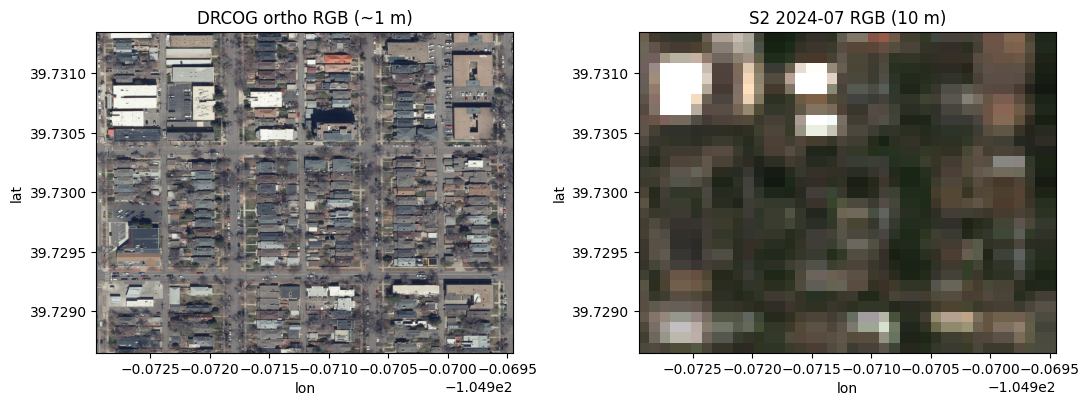

In [8]:
# === CELL 7: read S2 monthly stack back + co-registration sanity check ========
from google.colab import drive
try:
    drive.mount("/content/drive",force_remount= True)
except Exception:
    pass

stack = read_s2_drive_folder("/content/drive/MyDrive/s2_aoi_export")
print("stack:", stack["data"].shape, "(T, B, H, W)")
print("months:", len(stack["dates"]),
      "|", stack["dates"].min().date(), "->", stack["dates"].max().date())
print("bands:", stack["bands"])
print("valid-pixel fraction:", round(float(np.mean(~np.isnan(stack["data"][:, 0]))), 3))

# ortho RGB vs one S2 month, plotted on the SAME 4326 extent -> should overlay
import matplotlib.pyplot as plt
west, south, east, north = bbox
ext = [west, east, south, north]

rgb_ortho = np.transpose(ortho["array"][:3], (1, 2, 0))          # (H,W,3) uint8 [R,G,B]
ti = len(stack["dates"]) // 2                                    # a mid month
s2_rgb = np.clip(np.transpose(stack["data"][ti][[2, 1, 0]], (1, 2, 0)) * 3.0, 0, 1)

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].imshow(rgb_ortho, extent=ext); ax[0].set_title("DRCOG ortho RGB (~1 m)")
ax[1].imshow(s2_rgb, extent=ext)
ax[1].set_title(f"S2 {stack['dates'][ti].strftime('%Y-%m')} RGB (10 m)")
for a in ax:
    a.set_xlabel("lon"); a.set_ylabel("lat")
plt.tight_layout(); plt.show()

pixel (row=15, col=20) center lon=-104.971150 lat=39.730015


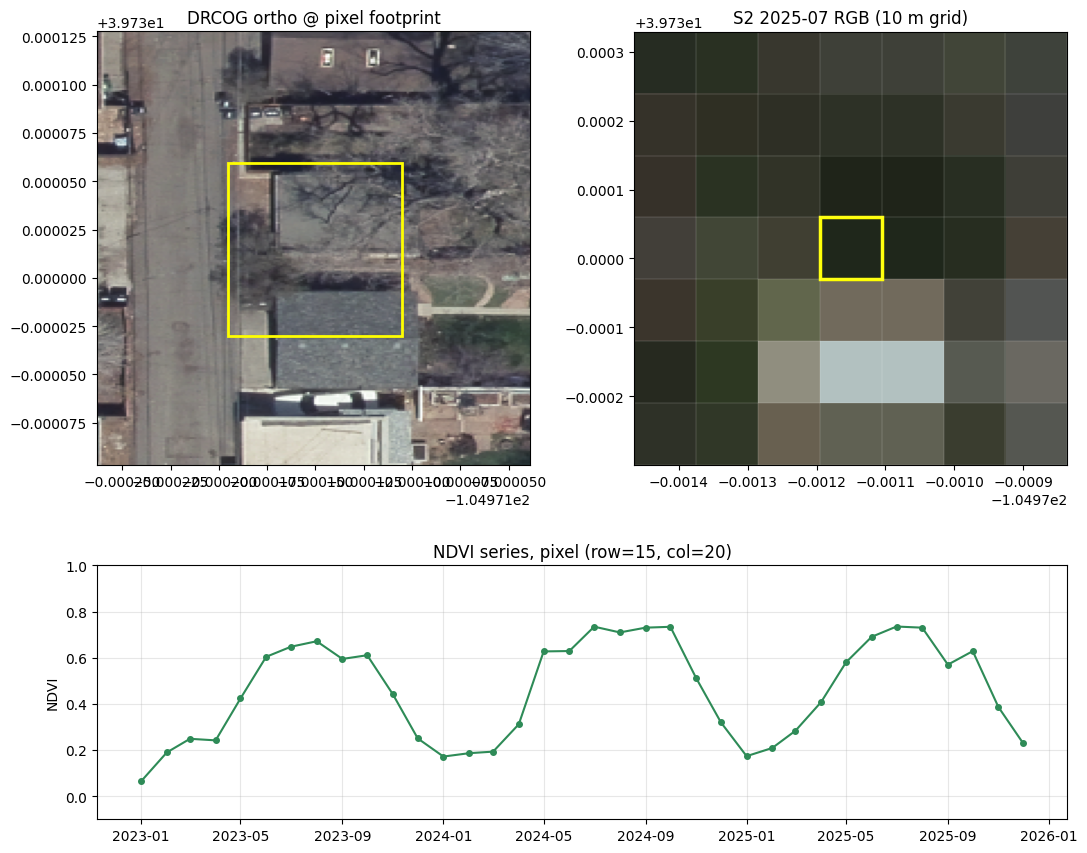

In [9]:

# === CELL 8: one S2 pixel -- ortho footprint, coarse-grid location, NDVI series
from rasterio.transform import rowcol
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt

# --- choose the pixel (default = center of the AOI) ---
H, W = stack["data"].shape[2], stack["data"].shape[3]
s2_row, s2_col = H // 2, W // 2          # change to inspect a different pixel
ctx     = 3                              # S2 pixels of context shown around it
margin  = 0.75                           # ortho zoom padding, in pixel-widths
stretch = 3.0                            # S2 RGB brightness

bands = stack["bands"]
i_red, i_nir = bands.index("B4"), bands.index("B8")
i_g, i_b     = bands.index("B3"), bands.index("B2")

# --- footprint of the chosen pixel in 4326 (from the S2 affine) ---
T = stack["transform"]
xl, yt = T * (s2_col, s2_row)
xr, yb = T * (s2_col + 1, s2_row + 1)
pw, pe = min(xl, xr), max(xl, xr)
ps, pn = min(yt, yb), max(yt, yb)
print(f"pixel (row={s2_row}, col={s2_col}) center "
      f"lon={ (pw+pe)/2:.6f} lat={ (ps+pn)/2:.6f}")

# --- greenest month, just for the RGB panels ---
nir_all = stack["data"][:, i_nir, s2_row, s2_col]
red_all = stack["data"][:, i_red, s2_row, s2_col]
ndvi    = (nir_all - red_all) / (nir_all + red_all)
mi = int(np.nanargmax(ndvi)) if np.isfinite(ndvi).any() else 0

fig, axd = plt.subplot_mosaic([["ortho", "s2"], ["ts", "ts"]],
                              figsize=(11, 9), gridspec_kw={"height_ratios": [2, 1]})

# --- ortho cropped to the pixel footprint (+margin), pixel boxed ---
OT = ortho["transform"]
mx, my = (pe - pw) * margin, (pn - ps) * margin
r0, c0 = rowcol(OT, pw - mx, pn + my)
r1, c1 = rowcol(OT, pe + mx, ps - my)
r0, r1 = sorted((max(0, r0), min(ortho["array"].shape[1], r1)))
c0, c1 = sorted((max(0, c0), min(ortho["array"].shape[2], c1)))
crop = np.transpose(ortho["array"][:3, r0:r1, c0:c1], (1, 2, 0))
ex0, ey0 = OT * (c0, r0)
ex1, ey1 = OT * (c1, r1)
axd["ortho"].imshow(crop, extent=[ex0, ex1, ey1, ey0])
axd["ortho"].add_patch(Rectangle((pw, ps), pe - pw, pn - ps,
                                  fill=False, edgecolor="yellow", lw=2))
axd["ortho"].set_title("DRCOG ortho @ pixel footprint")

# --- S2 neighborhood RGB, chosen pixel highlighted on the coarse grid ---
rr0, rr1 = max(0, s2_row - ctx), min(H, s2_row + ctx + 1)
cc0, cc1 = max(0, s2_col - ctx), min(W, s2_col + ctx + 1)
s2_rgb = np.clip(np.transpose(
    stack["data"][mi][[i_red, i_g, i_b], rr0:rr1, cc0:cc1], (1, 2, 0)) * stretch, 0, 1)
nx0, ny0 = T * (cc0, rr0)
nx1, ny1 = T * (cc1, rr1)
axd["s2"].imshow(s2_rgb, extent=[nx0, nx1, ny1, ny0])
for cc in range(cc0, cc1 + 1):
    axd["s2"].axvline((T * (cc, rr0))[0], color="w", lw=0.3, alpha=0.4)
for rr in range(rr0, rr1 + 1):
    axd["s2"].axhline((T * (cc0, rr))[1], color="w", lw=0.3, alpha=0.4)
axd["s2"].add_patch(Rectangle((pw, ps), pe - pw, pn - ps,
                              fill=False, edgecolor="yellow", lw=2.5))
axd["s2"].set_title(f"S2 {stack['dates'][mi].strftime('%Y-%m')} RGB (10 m grid)")

# --- NDVI time series for the pixel ---
axd["ts"].plot(stack["dates"], ndvi, "-o", ms=4, color="seagreen")
axd["ts"].set_ylabel("NDVI"); axd["ts"].set_ylim(-0.1, 1.0)
axd["ts"].grid(alpha=0.3)
axd["ts"].set_title(f"NDVI series, pixel (row={s2_row}, col={s2_col})")

plt.tight_layout(); plt.show()



A seasonal (np.int64(12), np.int64(18)): NDVI std=0.223 mean=0.387
B stable   (np.int64(17), np.int64(20)): NDVI std=0.076 mean=0.197


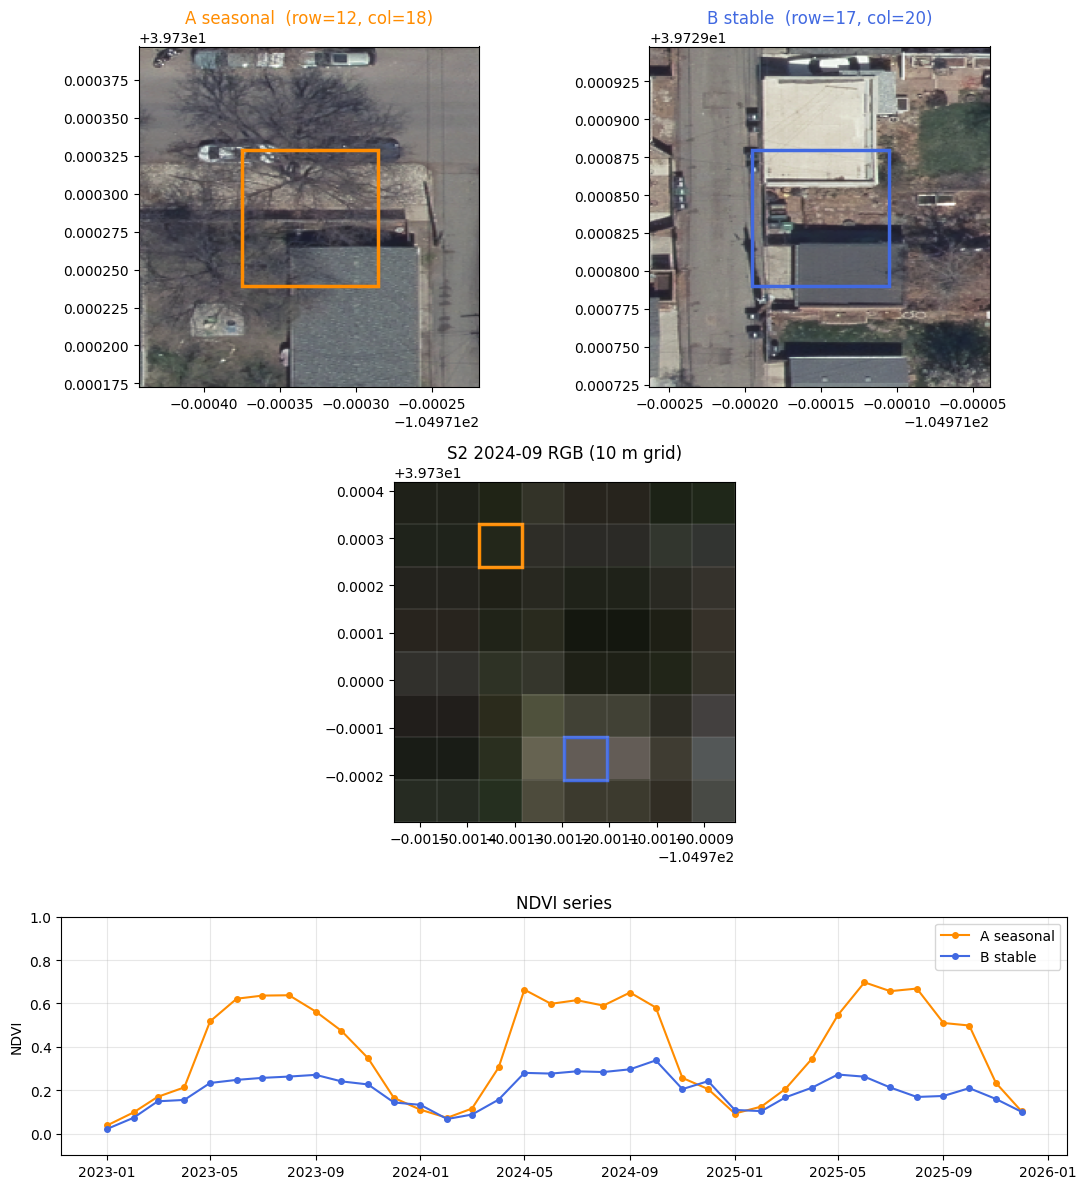

In [10]:

# === CELL 9: two contrasting pixels (seasonal vs stable) in one neighborhood ==
from rasterio.transform import rowcol
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt

i_red, i_nir = stack["bands"].index("B4"), stack["bands"].index("B8")
i_g, i_b     = stack["bands"].index("B3"), stack["bands"].index("B2")
T, OT = stack["transform"], ortho["transform"]
H, W = stack["data"].shape[2], stack["data"].shape[3]

block      = 6        # search neighborhood, in S2 pixels (keeps the two near each other)
min_valid  = 6        # require this many non-NaN months to consider a pixel
margin     = 0.75     # ortho zoom padding (pixel-widths)
stretch    = 3.0
COL_A, COL_B = "darkorange", "royalblue"   # A = seasonal, B = stable

ndvi = ((stack["data"][:, i_nir] - stack["data"][:, i_red]) /
        (stack["data"][:, i_nir] + stack["data"][:, i_red]))      # (T, H, W)

# --- pick the most-seasonal and most-stable pixel within a centered block ---
cr, cc = H // 2, W // 2
r_lo, r_hi = max(0, cr - block // 2), min(H, cr + block // 2)
c_lo, c_hi = max(0, cc - block // 2), min(W, cc + block // 2)
sub   = ndvi[:, r_lo:r_hi, c_lo:c_hi]
std   = np.where(np.isfinite(sub).sum(0) >= min_valid, np.nanstd(sub, 0), np.nan)
a = np.unravel_index(np.nanargmax(std), std.shape)   # biggest seasonal swing
b = np.unravel_index(np.nanargmin(std), std.shape)   # flattest
A = (r_lo + a[0], c_lo + a[1])
B = (r_lo + b[0], c_lo + b[1])
print(f"A seasonal {A}: NDVI std={np.nanstd(ndvi[:,A[0],A[1]]):.3f} "
      f"mean={np.nanmean(ndvi[:,A[0],A[1]]):.3f}")
print(f"B stable   {B}: NDVI std={np.nanstd(ndvi[:,B[0],B[1]]):.3f} "
      f"mean={np.nanmean(ndvi[:,B[0],B[1]]):.3f}")

def _pix_bounds(row, col):
    xl, yt = T * (col, row); xr, yb = T * (col + 1, row + 1)
    return min(xl, xr), min(yt, yb), max(xl, xr), max(yt, yb)   # w, s, e, n

def _ortho_crop(w, s, e, n):
    mx, my = (e - w) * margin, (n - s) * margin
    r0, c0 = rowcol(OT, w - mx, n + my)
    r1, c1 = rowcol(OT, e + mx, s - my)
    r0, r1 = sorted((max(0, r0), min(ortho["array"].shape[1], r1)))
    c0, c1 = sorted((max(0, c0), min(ortho["array"].shape[2], c1)))
    crop = np.transpose(ortho["array"][:3, r0:r1, c0:c1], (1, 2, 0))
    ex0, ey0 = OT * (c0, r0); ex1, ey1 = OT * (c1, r1)
    return crop, [ex0, ex1, ey1, ey0]

fig, axd = plt.subplot_mosaic([["oA", "oB"], ["s2", "s2"], ["ts", "ts"]],
                              figsize=(11, 12),
                              gridspec_kw={"height_ratios": [2, 2, 1.4]})

# --- ortho footprints of each pixel ---
for key, P, col, tag in [("oA", A, COL_A, "A seasonal"), ("oB", B, COL_B, "B stable")]:
    w, s, e, n = _pix_bounds(*P)
    crop, ext = _ortho_crop(w, s, e, n)
    axd[key].imshow(crop, extent=ext)
    axd[key].add_patch(Rectangle((w, s), e - w, n - s, fill=False, edgecolor=col, lw=2.5))
    axd[key].set_title(f"{tag}  (row={P[0]}, col={P[1]})", color=col)

# --- S2 neighborhood, both pixels highlighted on the coarse grid ---
mi = int(np.nanargmax(np.nanmean(sub, axis=(1, 2))))   # greenest month for display
rr0, rr1 = max(0, r_lo - 1), min(H, r_hi + 1)
cc0, cc1 = max(0, c_lo - 1), min(W, c_hi + 1)
s2_rgb = np.clip(np.transpose(
    stack["data"][mi][[i_red, i_g, i_b], rr0:rr1, cc0:cc1], (1, 2, 0)) * stretch, 0, 1)
nx0, ny0 = T * (cc0, rr0); nx1, ny1 = T * (cc1, rr1)
axd["s2"].imshow(s2_rgb, extent=[nx0, nx1, ny1, ny0])
for c_ in range(cc0, cc1 + 1):
    axd["s2"].axvline((T * (c_, rr0))[0], color="w", lw=0.3, alpha=0.4)
for r_ in range(rr0, rr1 + 1):
    axd["s2"].axhline((T * (cc0, r_))[1], color="w", lw=0.3, alpha=0.4)
for P, col in [(A, COL_A), (B, COL_B)]:
    w, s, e, n = _pix_bounds(*P)
    axd["s2"].add_patch(Rectangle((w, s), e - w, n - s, fill=False, edgecolor=col, lw=2.5))
axd["s2"].set_title(f"S2 {stack['dates'][mi].strftime('%Y-%m')} RGB (10 m grid)")

# --- NDVI series overlay ---
axd["ts"].plot(stack["dates"], ndvi[:, A[0], A[1]], "-o", ms=4, color=COL_A, label="A seasonal")
axd["ts"].plot(stack["dates"], ndvi[:, B[0], B[1]], "-o", ms=4, color=COL_B, label="B stable")
axd["ts"].set_ylabel("NDVI"); axd["ts"].set_ylim(-0.1, 1.0)
axd["ts"].grid(alpha=0.3); axd["ts"].legend()
axd["ts"].set_title("NDVI series")

plt.tight_layout(); plt.show()



In [11]:
# === CELL 10: data generator -- (fine ortho patch -> observed coarse series) ==
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from rasterio.transform import rowcol


class CoarsePixelDataset(Dataset):
    """One self-supervised sample per S2 pixel.

      X   : (4, P, P) ortho [R,G,B,NIR] in [0,1] -- the fine content in the pixel
      y   : observed coarse series. target="reflectance" -> (T, B);
            target="ndvi" -> (T, 1)  [note: NDVI mixes nonlinearly; prefer
            reconstructing reflectance and deriving NDVI afterward]
      m   : (T,) bool, True where the month is observed (not cloud/snow NaN)
      idx : (2,) the source (row, col) for traceability
    """
    def __init__(self, ortho, stack, patch=64, target="reflectance", min_valid=4):
        self.ortho_arr = ortho["array"]                 # (4, H, W) uint8
        self.OT, self.T = ortho["transform"], stack["transform"]
        self.data = stack["data"]                        # (T, B, Hs, Ws) float
        self.bands = stack["bands"]
        self.patch, self.target, self.min_valid = patch, target, min_valid
        self.i_red, self.i_nir = self.bands.index("B4"), self.bands.index("B8")

        valid_counts = np.isfinite(self.data[:, 0]).sum(0)          # (Hs, Ws)
        self.index = [tuple(int(v) for v in rc)
                      for rc in np.argwhere(valid_counts >= min_valid)]

    def __len__(self):
        return len(self.index)

    def _bounds(self, r, c):
        xl, yt = self.T * (c, r); xr, yb = self.T * (c + 1, r + 1)
        return min(xl, xr), min(yt, yb), max(xl, xr), max(yt, yb)    # w, s, e, n

    def _fine_patch(self, w, s, e, n):
        r0, c0 = rowcol(self.OT, w, n); r1, c1 = rowcol(self.OT, e, s)
        r0, r1 = sorted((max(0, r0), min(self.ortho_arr.shape[1], r1)))
        c0, c1 = sorted((max(0, c0), min(self.ortho_arr.shape[2], c1)))
        crop = self.ortho_arr[:, r0:r1, c0:c1].astype(np.float32) / 255.0
        t = torch.from_numpy(crop).unsqueeze(0)                      # (1,4,h,w)
        return F.interpolate(t, size=(self.patch, self.patch),
                             mode="area").squeeze(0)                 # (4,P,P)

    def __getitem__(self, i):
        r, c = self.index[i]
        X = self._fine_patch(*self._bounds(r, c))
        if self.target == "ndvi":
            nir, red = self.data[:, self.i_nir, r, c], self.data[:, self.i_red, r, c]
            y = ((nir - red) / (nir + red))[:, None]                 # (T,1)
        else:
            y = self.data[:, :, r, c]                                # (T,B)
        m = np.isfinite(y).all(axis=1)                               # (T,)
        y = np.nan_to_num(y.astype(np.float32), nan=0.0)
        return X, torch.from_numpy(y), torch.from_numpy(m), torch.tensor([r, c])


def make_loader(ortho, stack, batch_size=32, target="reflectance",
                patch=64, min_valid=4, shuffle=True):
    ds = CoarsePixelDataset(ortho, stack, patch=patch, target=target, min_valid=min_valid)
    return ds, DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


# sanity: build the generator and pull one batch
ds, loader = make_loader(ortho, stack, target="reflectance")
Xb, yb, mb, idxb = next(iter(loader))
print("samples:", len(ds))
print("X", tuple(Xb.shape), "| y", tuple(yb.shape), "| mask", tuple(mb.shape))
print("avg valid months/sample:", round(mb.float().sum(1).mean().item(), 1))


samples: 1240
X (32, 4, 64, 64) | y (32, 36, 6) | mask (32, 36)
avg valid months/sample: 36.0
